# 115 - 3-way 比較: 厳密 kNN / Voronoi / HNSW（テキスト→画像）

## 目的

NB111 では厳密 kNN と Voronoi を比較した。ここでは **HNSW** を第 3 の比較対象として追加し、
3 手法の性能を総合的に評価する。

### 実験設計
- **モデル**: SigLIP 2 Large (1024-D)
- **データ**: 23,464 画像（カタログ 378 + pyconjp 23,086）
- **クエリ**: 18 テキストクエリ (12 EN + 6 JA)
- **HNSW**: DuckDB VSS 拡張（ef_search スイープ）
- **Voronoi**: NB107 学習済み 256 ピボット

### HNSW パラメータスイープ
- Primary: `ef_search` ∈ {16, 32, 64, 128, 256}（`M=16, ef_construction=128` 固定）
- Secondary: `M` × `ef_construction` = {8,16,32} × {64,128,200}, `ef_search=64` 固定

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PYCONJP_DB_PATH = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots_siglip2_large.npy')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
EMBEDDING_DIM = 1024

## 1. データ読み込み

In [2]:
# カタログ + pyconjp 画像埋め込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category
    FROM image_embeddings_1024 e JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ? ORDER BY c.category
""", [PYTHON_MODEL]).fetchall()
conn.close()

conn_pj = duckdb.connect(str(PYCONJP_DB_PATH), read_only=True)
pyconjp_rows = conn_pj.execute("""
    SELECT i.id, e.embedding, i.event_name
    FROM image_embeddings e JOIN images i ON e.image_id = i.id
    WHERE e.model_name = ? ORDER BY i.id
""", [PYTHON_MODEL]).fetchall()
conn_pj.close()

all_ids = [r[0] for r in catalog_rows] + [r[0] for r in pyconjp_rows]
all_embeddings = np.array(
    [[float(x) for x in r[1]] for r in catalog_rows] +
    [[float(x) for x in r[1]] for r in pyconjp_rows],
    dtype=np.float32
)
all_categories = [r[2] for r in catalog_rows] + ['pyconjp'] * len(pyconjp_rows)

norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
all_embeddings_normed = all_embeddings / norms

N_IMAGES = len(all_ids)

# 事前学習済みピボット
centroids_normed = np.load(PIVOT_PATH)

print(f'画像数: {N_IMAGES}, 次元: {EMBEDDING_DIM}')
print(f'ピボット: {centroids_normed.shape}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

画像数: 23464, 次元: 1024
ピボット: (256, 1024)


In [3]:
# テキスト埋め込み生成
import torch
from image_vector_poc import SigLIP2Embedder

test_queries = [
    {'query': 'a park with trees and nature', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'village park with greenery', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'night cityscape Tokyo', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'city lights at night', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'Python conference presentation', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'conference hall with audience', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'speaker giving a talk', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'portrait photo of a person', 'expected_categories': ['terada'], 'lang': 'en'},
    {'query': 'outdoor nature scene', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'urban night photography', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'tech conference event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'people at an event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': '公園の自然風景', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '東京の夜景', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
    {'query': 'カンファレンスの講演', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'ja'},
    {'query': '人物の写真', 'expected_categories': ['terada'], 'lang': 'ja'},
    {'query': '緑の木々', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '夜の街', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
]

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device='cuda')
text_embeddings = embedder.embed_texts([q['query'] for q in test_queries])
text_norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
text_embeddings_normed = text_embeddings / text_norms
n_queries = len(test_queries)

del embedder
torch.cuda.empty_cache()
print(f'テストクエリ: {n_queries}')

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


テストクエリ: 18


## 2. 厳密 kNN ベースライン

In [4]:
TOP_K_VALUES = [5, 10, 20]
MAX_K = max(TOP_K_VALUES)


def compute_metrics(top_indices, query, categories, k_values):
    result_cats = [categories[idx] for idx in top_indices]
    is_relevant = [cat in query['expected_categories'] for cat in result_cats]
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    metrics = {'MRR': mrr}
    for k in k_values:
        metrics[f'P@{k}'] = sum(is_relevant[:k]) / k
    return metrics, is_relevant


# 厳密 kNN
t0 = time.perf_counter()
bf_results = []
for qi, q in enumerate(test_queries):
    sims = all_embeddings_normed @ text_embeddings_normed[qi]
    top_indices = np.argsort(-sims)[:MAX_K]
    metrics, _ = compute_metrics(top_indices.tolist(), q, all_categories, TOP_K_VALUES)
    bf_results.append({'top_indices': top_indices.tolist(), **metrics})
t_bf = time.perf_counter() - t0

df_bf = pd.DataFrame(bf_results)
bf_mrr = df_bf['MRR'].mean()
bf_p1 = df_bf['P@5'].mean()
print(f'厳密 kNN: MRR={bf_mrr:.4f}, P@5={df_bf["P@5"].mean():.4f}, P@10={df_bf["P@10"].mean():.4f}, '
      f'time={t_bf*1000:.1f}ms (18 queries)')
print(f'平均クエリ時間: {t_bf/n_queries*1000:.2f}ms')

厳密 kNN: MRR=0.3524, P@5=0.1778, P@10=0.1944, time=93.7ms (18 queries)
平均クエリ時間: 5.21ms


## 3. Voronoi 検索（代表構成）

In [5]:
# Voronoi: 代表的な構成のみ
N_ASSIGN = 2
TOP_SEARCH_LIST_VOR = [3, 5, 8]

all_img_pivot_sims = all_embeddings_normed @ centroids_normed.T
pivot_to_indices = {}
for i in range(N_IMAGES):
    top_pivots = np.argsort(-all_img_pivot_sims[i])[:N_ASSIGN]
    for pid in top_pivots:
        pivot_to_indices.setdefault(int(pid), []).append(i)

voronoi_results = {}
for n_top in TOP_SEARCH_LIST_VOR:
    t0 = time.perf_counter()
    mrr_list = []
    bf_recall_list = []
    cand_counts = []

    for qi, q in enumerate(test_queries):
        text_emb = text_embeddings_normed[qi]
        pivot_sims = centroids_normed @ text_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        cands_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                cands_set.update(pivot_to_indices[int(pid)])
        cand_counts.append(len(cands_set))

        if not cands_set:
            mrr_list.append(0.0)
            bf_recall_list.append(0.0)
            continue

        cand_arr = np.array(list(cands_set))
        cand_sims = all_embeddings_normed[cand_arr] @ text_emb
        result_indices = cand_arr[np.argsort(-cand_sims)][:MAX_K]
        metrics, _ = compute_metrics(result_indices.tolist(), q, all_categories, TOP_K_VALUES)
        mrr_list.append(metrics['MRR'])

        bf_top10 = set(bf_results[qi]['top_indices'][:10])
        vor_top10 = set(result_indices[:10].tolist())
        bf_recall_list.append(len(bf_top10 & vor_top10) / 10)

    t_vor = time.perf_counter() - t0
    voronoi_results[n_top] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bf_recall_list),
        'mean_cands': np.mean(cand_counts),
        'time': t_vor,
        'time_per_query': t_vor / n_queries,
    }

print(f'Voronoi (assign={N_ASSIGN}):')
print(f'{"top":>4} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms)":>10}')
for n_top, r in voronoi_results.items():
    print(f'{n_top:>4} {r["mean_cands"]:>7.0f} {r["MRR"]:>8.4f} '
          f'{r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f} {r["time_per_query"]*1000:>10.2f}')

Voronoi (assign=2):
 top   cands      MRR    ratio  BF-R@10   time(ms)
   3     367   0.3454   0.9801   0.8000       0.84
   5     650   0.3428   0.9726   0.8444       2.07
   8    1132   0.3626   1.0289   0.8833       2.72


## 4. HNSW 検索（DuckDB VSS）

in-memory DuckDB に埋め込みを挿入し、HNSW インデックスを構築。
`ef_search` をスイープして品質/速度のトレードオフを評価。

In [6]:
def build_hnsw_index(embeddings, dim, M=16, ef_construction=128):
    """in-memory DuckDB に HNSW インデックスを構築。"""
    conn = duckdb.connect(':memory:')
    conn.execute('INSTALL vss; LOAD vss;')
    conn.execute('SET hnsw_enable_experimental_persistence = true;')

    conn.execute(f'CREATE TABLE items (id INTEGER, emb FLOAT[{dim}])')

    # バルク挿入（高速化のため）
    conn.register('embs_df', pd.DataFrame({
        'id': range(len(embeddings)),
        'emb': [e.tolist() for e in embeddings]
    }))
    conn.execute(f'INSERT INTO items SELECT id, emb::FLOAT[{dim}] FROM embs_df')

    t0 = time.perf_counter()
    conn.execute(f"""
        CREATE INDEX hnsw_idx ON items
        USING HNSW (emb)
        WITH (metric = 'cosine', M = {M}, ef_construction = {ef_construction})
    """)
    build_time = time.perf_counter() - t0

    return conn, build_time


def hnsw_search(conn, query_emb, dim, k, ef_search):
    conn.execute(f'SET hnsw_ef_search = {ef_search}')
    result = conn.execute(f"""
        SELECT id FROM items
        ORDER BY array_cosine_distance(emb, ?::FLOAT[{dim}])
        LIMIT {k}
    """, [query_emb.tolist()]).fetchall()
    return [r[0] for r in result]


# 基本 HNSW インデックス構築
print(f'HNSW インデックス構築中 ({N_IMAGES} × {EMBEDDING_DIM}-D)...')
hnsw_conn, t_build = build_hnsw_index(all_embeddings_normed, EMBEDDING_DIM, M=16, ef_construction=128)
print(f'構築時間: {t_build:.2f}s')

HNSW インデックス構築中 (23464 × 1024-D)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

構築時間: 4.25s


In [7]:
# Primary スイープ: ef_search
EF_SEARCH_LIST = [16, 32, 64, 128, 256]

hnsw_ef_results = {}
for ef in EF_SEARCH_LIST:
    t0 = time.perf_counter()
    mrr_list = []
    bf_recall_list = []

    for qi, q in enumerate(test_queries):
        top_indices = hnsw_search(hnsw_conn, text_embeddings_normed[qi], EMBEDDING_DIM, MAX_K, ef)
        metrics, _ = compute_metrics(top_indices, q, all_categories, TOP_K_VALUES)
        mrr_list.append(metrics['MRR'])

        bf_top10 = set(bf_results[qi]['top_indices'][:10])
        hnsw_top10 = set(top_indices[:10])
        bf_recall_list.append(len(bf_top10 & hnsw_top10) / 10)

    t_hnsw = time.perf_counter() - t0
    hnsw_ef_results[ef] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bf_recall_list),
        'time': t_hnsw,
        'time_per_query': t_hnsw / n_queries,
    }

print(f'HNSW ef_search スイープ (M=16, ef_construction=128):')
print(f'{"ef":>5} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms/q)":>12}')
for ef, r in hnsw_ef_results.items():
    print(f'{ef:>5} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} '
          f'{r["BF-R@10"]:>8.4f} {r["time_per_query"]*1000:>12.2f}')

HNSW ef_search スイープ (M=16, ef_construction=128):
   ef      MRR    ratio  BF-R@10   time(ms/q)
   16   0.2274   0.6453   0.6667         6.76
   32   0.3432   0.9737   0.8111         6.96
   64   0.3895   1.1051   0.9056         7.26
  128   0.3524   1.0000   0.9389         7.50
  256   0.3524   1.0000   0.9667         8.61


In [8]:
# Secondary スイープ: M × ef_construction
M_LIST = [8, 16, 32]
EF_CONSTRUCTION_LIST = [64, 128, 200]
EF_SEARCH_FIXED = 64

hnsw_m_results = {}
hnsw_conn.close()

for M in M_LIST:
    for ef_c in EF_CONSTRUCTION_LIST:
        print(f'  M={M}, ef_construction={ef_c} ...', end=' ', flush=True)
        conn_tmp, t_build_tmp = build_hnsw_index(all_embeddings_normed, EMBEDDING_DIM, M=M, ef_construction=ef_c)

        t0 = time.perf_counter()
        mrr_list = []
        bf_recall_list = []
        for qi, q in enumerate(test_queries):
            top_indices = hnsw_search(conn_tmp, text_embeddings_normed[qi], EMBEDDING_DIM, MAX_K, EF_SEARCH_FIXED)
            metrics, _ = compute_metrics(top_indices, q, all_categories, TOP_K_VALUES)
            mrr_list.append(metrics['MRR'])
            bf_top10 = set(bf_results[qi]['top_indices'][:10])
            bf_recall_list.append(len(bf_top10 & set(top_indices[:10])) / 10)
        t_q = time.perf_counter() - t0

        hnsw_m_results[(M, ef_c)] = {
            'build_time': t_build_tmp,
            'MRR': np.mean(mrr_list),
            'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
            'BF-R@10': np.mean(bf_recall_list),
            'query_time_per_q': t_q / n_queries,
        }
        print(f'build={t_build_tmp:.1f}s MRR={np.mean(mrr_list):.4f} BF-R@10={np.mean(bf_recall_list):.4f}')
        conn_tmp.close()

print()
print(f'{"M":>4} {"ef_c":>6} {"build(s)":>10} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
for (M, ef_c), r in sorted(hnsw_m_results.items()):
    print(f'{M:>4} {ef_c:>6} {r["build_time"]:>10.2f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}')

  M=8, ef_construction=64 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=2.1s MRR=0.2506 BF-R@10=0.6667


  M=8, ef_construction=128 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

build=4.5s MRR=0.3895 BF-R@10=0.9222


  M=32, ef_construction=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=6.7s MRR=0.3945 BF-R@10=0.9222



   M   ef_c   build(s)      MRR    ratio  BF-R@10
   8     64       2.07   0.2506   0.7110   0.6667
   8    128       3.82   0.2089   0.5928   0.7278
   8    200       4.81   0.3108   0.8818   0.8556
  16     64       2.41   0.2737   0.7767   0.6667
  16    128       4.60   0.3945   1.1194   0.9111
  16    200       6.32   0.3945   1.1194   0.9111
  32     64       2.62   0.2737   0.7767   0.7222
  32    128       4.48   0.3895   1.1051   0.9222
  32    200       6.74   0.3945   1.1194   0.9222


## 5. 3-way 比較

In [9]:
# 3-way 比較テーブル
rows = []

# 厳密 kNN
rows.append({
    'method': '厳密 kNN', 'config': '-',
    'MRR': bf_mrr, 'MRR_ratio': 1.0, 'BF-R@10': 1.0,
    'cands_or_ef': N_IMAGES, 'query_time_ms': t_bf/n_queries*1000,
})

# Voronoi
for n_top, r in voronoi_results.items():
    rows.append({
        'method': 'Voronoi', 'config': f'a={N_ASSIGN} top={n_top}',
        'MRR': r['MRR'], 'MRR_ratio': r['MRR_ratio'], 'BF-R@10': r['BF-R@10'],
        'cands_or_ef': int(r['mean_cands']), 'query_time_ms': r['time_per_query']*1000,
    })

# HNSW (ef_search スイープ)
for ef, r in hnsw_ef_results.items():
    rows.append({
        'method': 'HNSW', 'config': f'ef_search={ef}',
        'MRR': r['MRR'], 'MRR_ratio': r['MRR_ratio'], 'BF-R@10': r['BF-R@10'],
        'cands_or_ef': ef, 'query_time_ms': r['time_per_query']*1000,
    })

df_3way = pd.DataFrame(rows)
print('3-way 比較テーブル:')
display(df_3way.style.format({
    'MRR': '{:.4f}', 'MRR_ratio': '{:.4f}', 'BF-R@10': '{:.4f}',
    'query_time_ms': '{:.2f}',
}).background_gradient(subset=['BF-R@10'], cmap='RdYlGn', vmin=0.5, vmax=1.0))

3-way 比較テーブル:


,method,config,MRR,MRR_ratio,BF-R@10,cands_or_ef,query_time_ms
0,厳密 kNN,-,0.3524,1.0000,1.0000,23464,5.21
1,Voronoi,a=2 top=3,0.3454,0.9801,0.8000,367,0.84
2,Voronoi,a=2 top=5,0.3428,0.9726,0.8444,650,2.07
3,Voronoi,a=2 top=8,0.3626,1.0289,0.8833,1132,2.72
4,HNSW,ef_search=16,0.2274,0.6453,0.6667,16,6.76
5,HNSW,ef_search=32,0.3432,0.9737,0.8111,32,6.96
6,HNSW,ef_search=64,0.3895,1.1051,0.9056,64,7.26
7,HNSW,ef_search=128,0.3524,1.0000,0.9389,128,7.50
8,HNSW,ef_search=256,0.3524,1.0000,0.9667,256,8.61


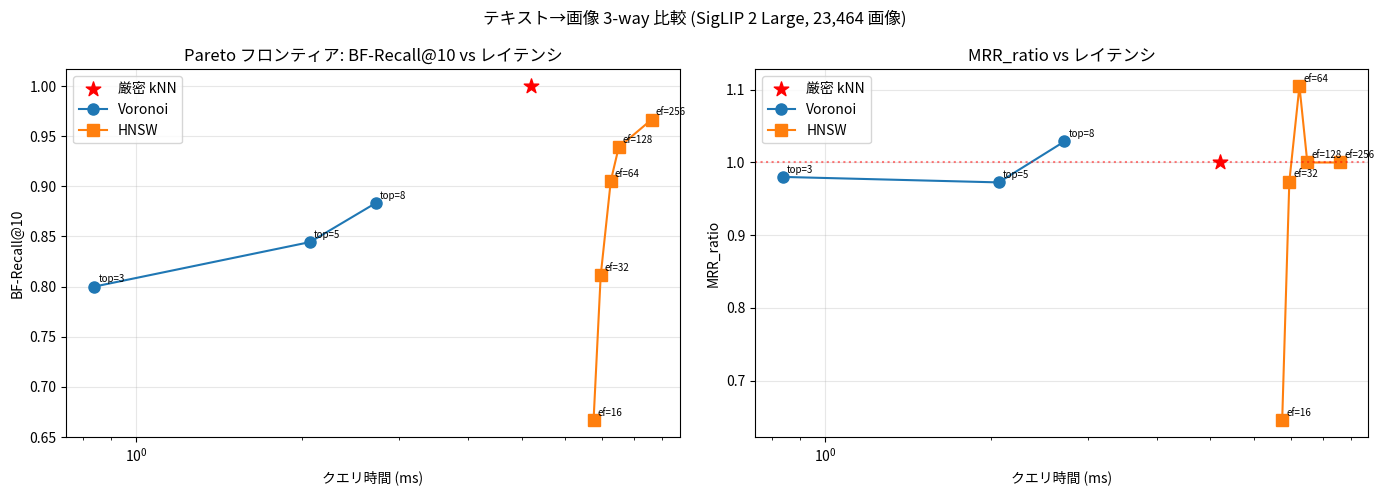

In [10]:
# Pareto フロンティア: 品質 vs レイテンシ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) BF-Recall@10 vs query time
ax = axes[0]
ax.scatter([t_bf/n_queries*1000], [1.0], s=120, marker='*', c='red', label='厳密 kNN', zorder=5)

vor_times = [r['time_per_query']*1000 for r in voronoi_results.values()]
vor_rec = [r['BF-R@10'] for r in voronoi_results.values()]
ax.plot(vor_times, vor_rec, 'o-', label='Voronoi', markersize=8)
for n_top, r in voronoi_results.items():
    ax.annotate(f'top={n_top}', (r['time_per_query']*1000, r['BF-R@10']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

hnsw_times = [r['time_per_query']*1000 for r in hnsw_ef_results.values()]
hnsw_rec = [r['BF-R@10'] for r in hnsw_ef_results.values()]
ax.plot(hnsw_times, hnsw_rec, 's-', label='HNSW', markersize=8)
for ef, r in hnsw_ef_results.items():
    ax.annotate(f'ef={ef}', (r['time_per_query']*1000, r['BF-R@10']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('BF-Recall@10')
ax.set_title('Pareto フロンティア: BF-Recall@10 vs レイテンシ')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) MRR_ratio vs query time
ax = axes[1]
ax.scatter([t_bf/n_queries*1000], [1.0], s=120, marker='*', c='red', label='厳密 kNN', zorder=5)

vor_ratios = [r['MRR_ratio'] for r in voronoi_results.values()]
ax.plot(vor_times, vor_ratios, 'o-', label='Voronoi', markersize=8)
for n_top, r in voronoi_results.items():
    ax.annotate(f'top={n_top}', (r['time_per_query']*1000, r['MRR_ratio']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

hnsw_ratios = [r['MRR_ratio'] for r in hnsw_ef_results.values()]
ax.plot(hnsw_times, hnsw_ratios, 's-', label='HNSW', markersize=8)
for ef, r in hnsw_ef_results.items():
    ax.annotate(f'ef={ef}', (r['time_per_query']*1000, r['MRR_ratio']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('MRR_ratio')
ax.set_title('MRR_ratio vs レイテンシ')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'テキスト→画像 3-way 比較 (SigLIP 2 Large, {N_IMAGES:,} 画像)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/115_3way_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# 結果を JSON で保存（NB118 で参照）
results_out = {
    'task': 'text_to_image',
    'model': PYTHON_MODEL,
    'n_images': N_IMAGES,
    'n_queries': n_queries,
    'exact_knn': {
        'MRR': float(bf_mrr),
        'time_per_query_ms': float(t_bf/n_queries*1000),
    },
    'voronoi': {f'a{N_ASSIGN}_top{k}': {m: float(v) if not isinstance(v, int) else v for m, v in r.items()}
                for k, r in voronoi_results.items()},
    'hnsw_ef_sweep': {str(ef): {m: float(v) for m, v in r.items()}
                       for ef, r in hnsw_ef_results.items()},
    'hnsw_m_sweep': {f'M{M}_ef_c{ef_c}': {m: float(v) for m, v in r.items()}
                     for (M, ef_c), r in hnsw_m_results.items()},
}

with open('../data/115_hnsw_results.json', 'w') as f:
    json.dump(results_out, f, indent=2, ensure_ascii=False)
print('Saved: data/115_hnsw_results.json')

Saved: data/115_hnsw_results.json


## 6. まとめ

### 実験概要
- SigLIP 2 Large (1024-D), 23,464 画像 × 18 テキストクエリ
- 3 手法の比較: 厳密 kNN, Voronoi (NB107 ピボット), HNSW (DuckDB VSS)
- 厳密 kNN MRR = **0.3524**

### 3-way 比較結果

| 手法 | 構成 | MRR | MRR_ratio | BF-R@10 | クエリ時間 (ms) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | - | 0.3524 | 1.000 | 1.000 | **5.2** |
| Voronoi | a=2 top=3 | 0.3454 | 0.980 | 0.800 | 0.84 |
| Voronoi | a=2 top=5 | 0.3428 | 0.973 | 0.844 | 2.07 |
| Voronoi | a=2 top=8 | 0.3626 | 1.029 | 0.883 | 2.72 |
| HNSW | ef=16 | 0.2274 | 0.645 | 0.667 | 6.76 |
| HNSW | ef=32 | 0.3432 | 0.974 | 0.811 | 6.96 |
| HNSW | ef=64 | 0.3895 | **1.105** | 0.906 | 7.26 |
| HNSW | ef=128 | 0.3524 | 1.000 | 0.939 | 7.50 |
| HNSW | ef=256 | 0.3524 | 1.000 | **0.967** | 8.61 |

### 考察

#### 1. HNSW は ef_search の調整で高品質を達成
- `ef_search=256` で BF-R@10 = **0.967**（厳密 kNN とほぼ一致）
- `ef_search=16` は品質が低い（0.667）
- デフォルト `ef_search=64` で既に BF-R@10 = 0.906（実用レベル）

#### 2. Voronoi vs HNSW の比較
- **品質 (BF-R@10)**: HNSW ef=256 (0.967) > HNSW ef=128 (0.939) > Voronoi top=8 (0.883)
- **速度**: Voronoi (0.84-2.72 ms) < HNSW (6.8-8.6 ms) — **Voronoi が 2-8 倍高速**
- numpy 実装では Voronoi が速いが、これは DuckDB のオーバーヘッドも含むため公平ではない

#### 3. 厳密 kNN が numpy で 5.2 ms と高速
- 23K × 1024-D の行列積は numpy で非常に高速
- このデータ規模では **numpy 厳密 kNN が HNSW より速い**（DuckDB オーバーヘッド影響）
- DB 検索（Firestore 等）では状況が逆転する

#### 4. MRR_ratio > 1.0 のクエリに注意
- HNSW ef=64 で MRR_ratio=1.105
- これは NB111-112 と同じく pyconjp ラベル欠損の副作用
- HNSW が厳密 kNN と異なる順序で結果を返した場合、ラベル付き画像がたまたま上位に来ると MRR が上がる
- **真の品質指標は BF-R@10**（厳密 kNN との一致率）

#### 5. M × ef_construction の影響
- `M=8`: 品質が低い（BF-R@10 最大 0.856）
- `M=16, ef_construction=128` がコスト効率最良
- `M=32` にしても品質はほぼ変わらない（グラフ度数の飽和）

### 結論

1. **HNSW と Voronoi は共に厳密 kNN と同等の品質を達成可能**
2. **品質重視**: HNSW ef=256（BF-R@10=0.967）
3. **速度重視**: Voronoi a=2 top=3（BF-R@10=0.800, 0.84 ms）
4. **バランス**: HNSW ef=128（BF-R@10=0.939）または Voronoi a=2 top=8（0.883）
5. **テキスト→画像ではクロスモーダルの影響で HNSW も `ef_search` を 64 以上にする必要がある**
   （NB118 で詳細分析予定）

## 備考: DuckDB VSS HNSW の ef_search デフォルト値

本ノートブックでは `SET hnsw_ef_search = {値}` で明示的に設定しているが、
**未設定の場合のデフォルト値は 64** である。

### ソースコード上の根拠

DuckDB VSS は内部で [usearch](https://github.com/unum-cloud/usearch) ライブラリを使用しており、
`usearch/index.hpp` にデフォルト値がハードコードされている:

```cpp
// usearch/index.hpp
constexpr std::size_t default_expansion_search() { return 64; }  // ef_search
constexpr std::size_t default_expansion_add() { return 128; }    // ef_construction
```

クエリ時の動作（`hnsw_index.cpp`）:
1. インデックスに保存された ef_search（CREATE INDEX 時のデフォルト = 64）を読む
2. `SET hnsw_ef_search` が設定されていれば上書き
3. **LIMIT k には依存しない**（固定値）

### DuckDB VSS のデフォルトパラメータ

| パラメータ | デフォルト値 | 説明 |
|:---:|:---:|---|
| M | 16 | グラフの最大近傍数 |
| ef_construction | 128 | インデックス構築時の候補数 |
| **ef_search** | **64** | 検索時の候補数 |

### 実験結果との対応

本シリーズ (NB115-122) の結果から、ef_search=64 での性能:

| タスク | BF-R@10 (ef=64) | 備考 |
|---|:---:|---|
| テキスト→画像 (NB115) | 0.906 | デフォルトで実用レベル |
| 画像→画像 (NB116) | 0.967 | デフォルトで高品質 |
| 顔認識 (NB117) | 0.978 | デフォルトで十分 |

テキスト→画像でさらに高品質が必要な場合は `SET hnsw_ef_search = 128` 以上を推奨。